In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt


In [2]:
env=gym.make("Taxi-v3", render_mode="rgb_array")

In [3]:
env.reset()

(64, {'prob': 1.0, 'action_mask': array([1, 0, 1, 1, 0, 0], dtype=int8)})

In [4]:
img=env.render()

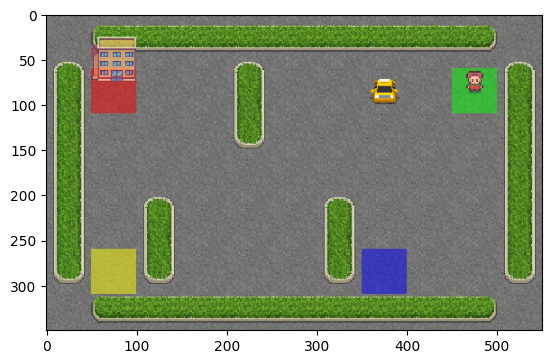

In [5]:
plt.imshow(img)
plt.show()

There are 500 states and 6 actions.

In [6]:
n_states=env.observation_space.n
n_actions=env.action_space.n
n_states, n_actions

(np.int64(500), np.int64(6))

In [7]:
Q=np.zeros([n_states,n_actions])

In [8]:
Q

array([[0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.]], shape=(500, 6))

In [9]:
G=0 #G is for sum of rewards.
alpha=0.618

Now i will apply for 1 episode.

In [ ]:
for episode in range(1,2):
  done=False
  G,reward=0,0
  state=env.reset()[0]
  while reward!=20:
    action=np.argmax(Q[state])
    state2,reward,done, done_, info=env.step(action)
    Q[state,action]+=alpha*(reward+np.max(Q[state2])-Q[state,action])
    G+=reward
    state=state2

print("all reward {}".format(G))

all reward -1210


In [11]:
Q

array([[ 0.      ,  0.      ,  0.      ,  0.      ,  0.      ,  0.      ],
       [ 0.      ,  0.      ,  0.      ,  0.      ,  0.      ,  0.      ],
       [ 0.      ,  0.      ,  0.      ,  0.      ,  0.      ,  0.      ],
       ...,
       [-1.236   , -0.854076, -1.236   , -1.236   , -6.18    , -6.18    ],
       [ 0.      ,  0.      ,  0.      ,  0.      ,  0.      ,  0.      ],
       [ 0.      ,  0.      ,  0.      ,  0.      ,  0.      ,  0.      ]],
      shape=(500, 6))

In [12]:
episodes=3000
Q=np.zeros([n_states,n_actions])

In [13]:
for episode in range(1,episodes+1):
  done=False
  G,reward=0,0
  state=env.reset()[0]
  while reward!=20:
    action=np.argmax(Q[state])
    state2,reward,done, done_,info=env.step(action)
    Q[state,action]+=alpha*(reward+np.max(Q[state2])-Q[state,action])
    G+=reward
    state=state2
  if episode%100==0:
    print("episode:{} sum of reward:{}".format(episode,G))



episode:100 sum of reward:-453
episode:200 sum of reward:7
episode:300 sum of reward:11
episode:400 sum of reward:6
episode:500 sum of reward:8
episode:600 sum of reward:9
episode:700 sum of reward:8
episode:800 sum of reward:12
episode:900 sum of reward:8
episode:1000 sum of reward:6
episode:1100 sum of reward:4
episode:1200 sum of reward:4
episode:1300 sum of reward:10
episode:1400 sum of reward:7
episode:1500 sum of reward:6
episode:1600 sum of reward:6
episode:1700 sum of reward:11
episode:1800 sum of reward:6
episode:1900 sum of reward:6
episode:2000 sum of reward:7
episode:2100 sum of reward:5
episode:2200 sum of reward:7
episode:2300 sum of reward:9
episode:2400 sum of reward:6
episode:2500 sum of reward:6
episode:2600 sum of reward:9
episode:2700 sum of reward:5
episode:2800 sum of reward:11
episode:2900 sum of reward:9
episode:3000 sum of reward:12


In [14]:
actions={
          0:"South",
          1:"North",
          2:"East",
          3:"West",
          4:"Pick Up",
          5:"Drop off"
}

In [17]:
state=env.reset()
done=None

In [18]:
state

(461, {'prob': 1.0, 'action_mask': array([0, 1, 1, 0, 0, 0], dtype=int8)})


 North


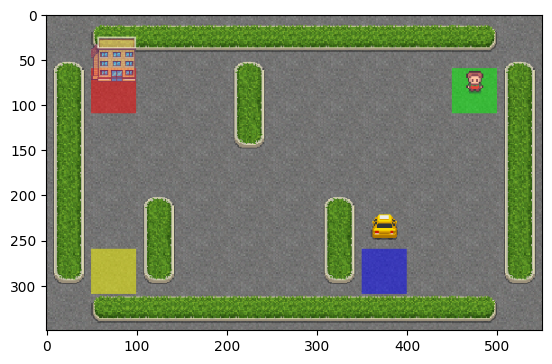


 North


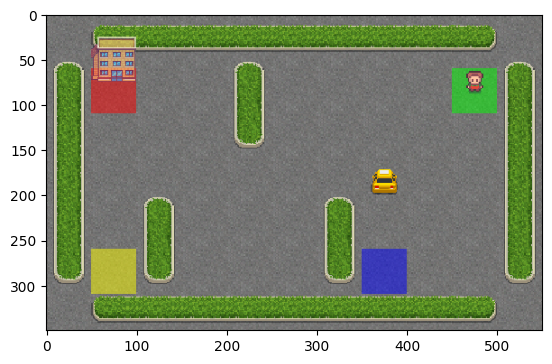


 East


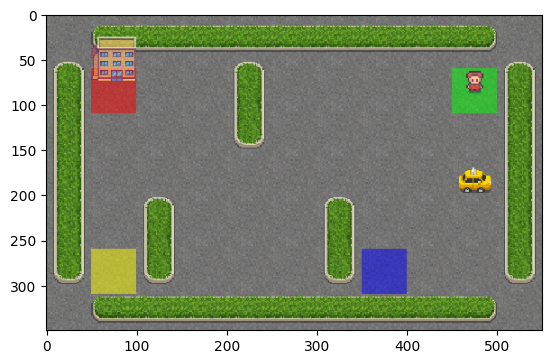


 North


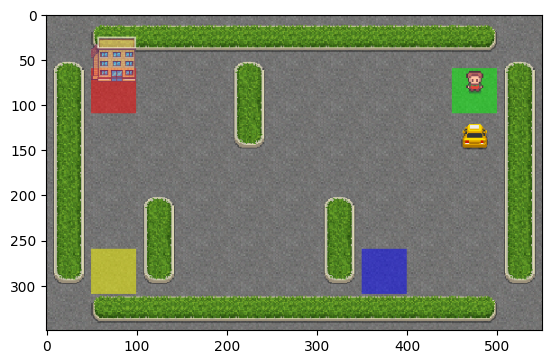


 North


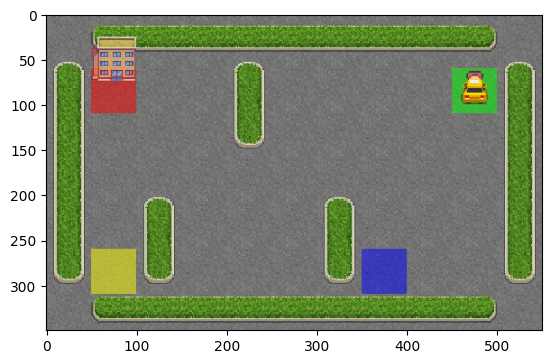


 Pick Up


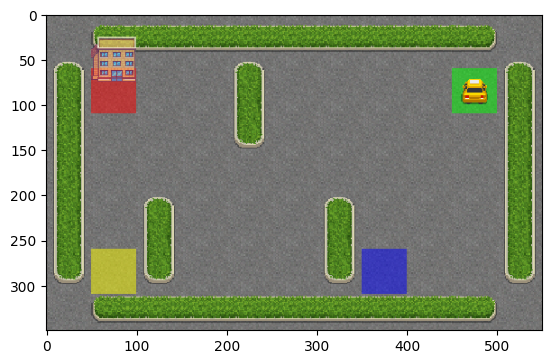


 South


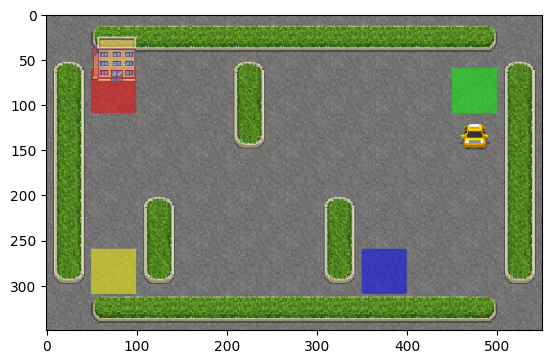


 West


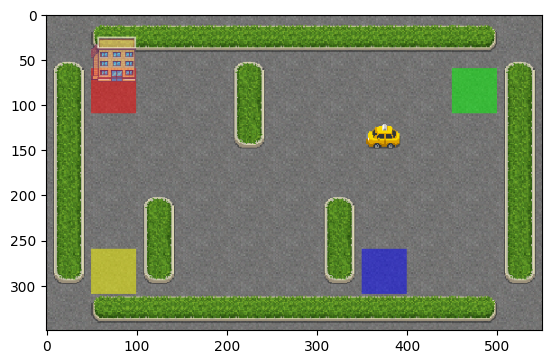


 South


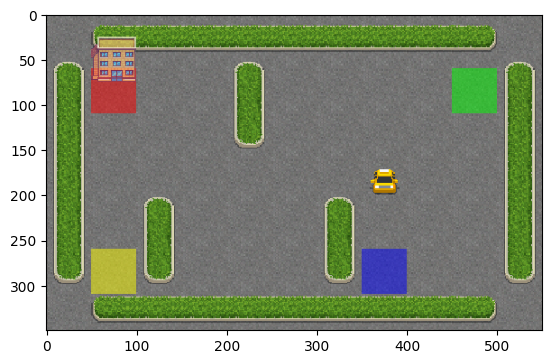


 West


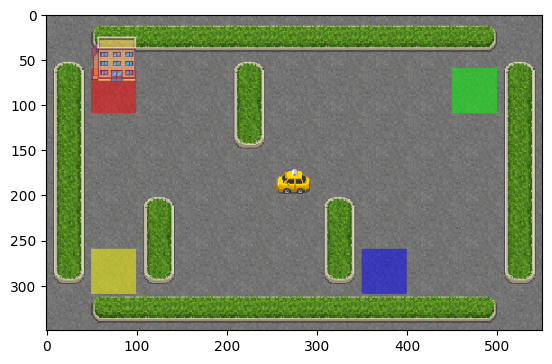


 West


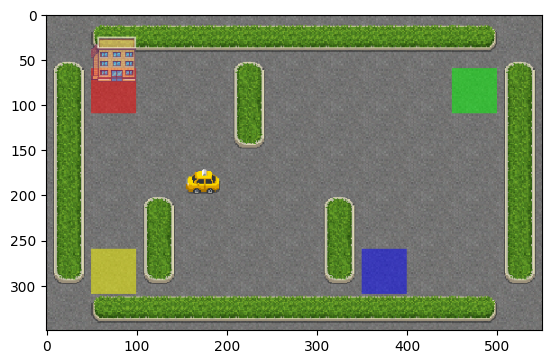


 North


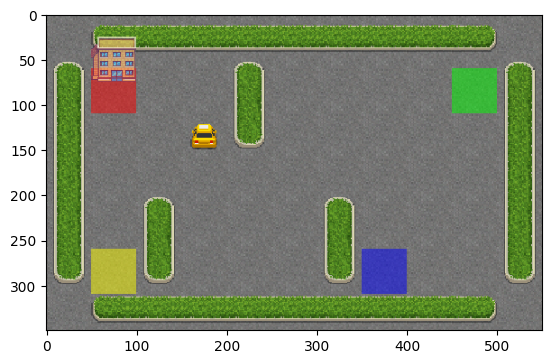


 West


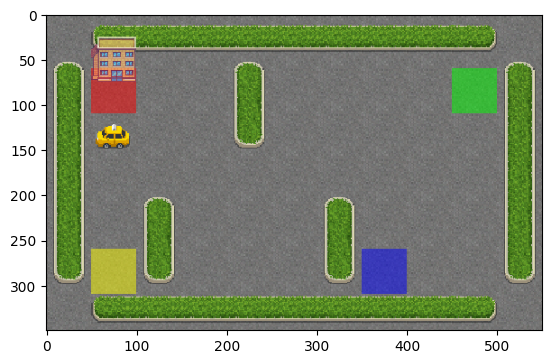


 North


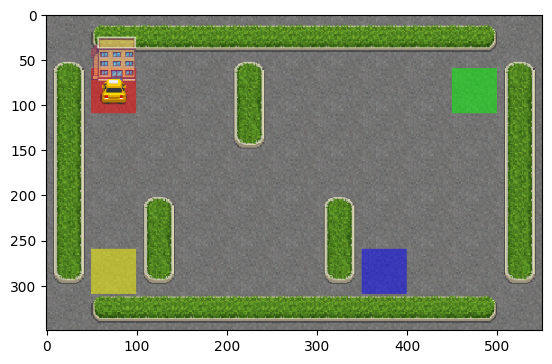


 Drop off


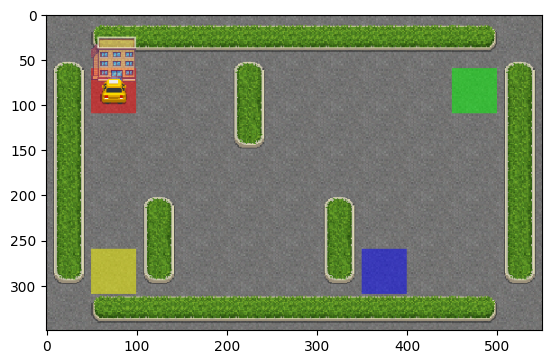

In [16]:
while done!=True:
  action=np.argmax(Q[state])
  state,reward,done, done_,info=env.step(action)
  output=actions.get(action)
  print("\n",f"{output}")
  img=env.render()
  plt.imshow(img)
  plt.show()
